# LAB 7 —  Object Detection

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 

## Learning objectives
**Context:** you will fine-tune a small YOLO detector on a small blood-cell dataset and analyze the results.


## Dataset
We will use the **BCCD Blood Cell Detection Dataset**, which contains microscope images with bounding-box annotations for:

- `RBC` — red blood cells
- `WBC` — white blood cells
- `Platelets`



>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


# 0. Installation


In [1]:
!pip install -q ultralytics opencv-python matplotlib pyyaml lxml

# 1. Imports and hardware configuration

This cell automatically selects GPU if available.  
If you want to force CPU mode, set `FORCE_CPU = True`.

In [2]:
from pathlib import Path
import os
import random
import shutil
import zipfile
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

FORCE_CPU = False  

if torch.cuda.is_available() and not FORCE_CPU:
    DEVICE = 0
    HARDWARE = "GPU"
else:
    DEVICE = "cpu"
    HARDWARE = "CPU"

print("Hardware mode:", HARDWARE)
print("Training device:", DEVICE)

if HARDWARE == "GPU":
    IMG_SIZE = 416
    EPOCHS = 15
    BATCH = 8
    MAX_IMAGES = 160
else:
    IMG_SIZE = 320
    EPOCHS = 150
    BATCH = 8
    MAX_IMAGES = 160

print(f"IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH={BATCH}, MAX_IMAGES={MAX_IMAGES}")

Hardware mode: CPU
Training device: cpu
IMG_SIZE=320, EPOCHS=150, BATCH=8, MAX_IMAGES=160


# 2. Download the dataset

We download BCCD from GitHub.  
The original annotations are in **Pascal VOC XML format**, so we will convert them to **YOLO format** later.

Expected original structure:

```text
BCCD/
├── Annotations/
├── JPEGImages/
└── ImageSets/
```

In [3]:
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
WORKDIR = ROOT / "object_detection_tp"
RAW_DIR = WORKDIR / "raw_bccd"
YOLO_DIR = WORKDIR / "bccd_yolo"

WORKDIR.mkdir(parents=True, exist_ok=True)

url = "https://github.com/Shenggan/BCCD_Dataset/archive/refs/heads/master.zip"
zip_path = WORKDIR / "bccd_master.zip"

if not zip_path.exists():
    print("Downloading BCCD dataset...")
    urllib.request.urlretrieve(url, zip_path)
else:
    print("Zip file already exists.")

if not RAW_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(WORKDIR)
    extracted = WORKDIR / "BCCD_Dataset-master" / "BCCD"
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for item in extracted.iterdir():
        shutil.copytree(item, RAW_DIR / item.name, dirs_exist_ok=True)
else:
    print("Raw dataset already exists.")

print("RAW_DIR:", RAW_DIR)
print("Number of images:", len(list((RAW_DIR / "JPEGImages").glob("*.jpg"))))
print("Number of annotations:", len(list((RAW_DIR / "Annotations").glob("*.xml"))))

Zip file already exists.
Raw dataset already exists.
RAW_DIR: /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/raw_bccd
Number of images: 364
Number of annotations: 364


# 3. Understand annotation formats

## 3.1 Pascal VOC format

The original dataset uses XML files. A bounding box is stored as:

```text
xmin, ymin, xmax, ymax
```

These are pixel coordinates.

## 3.2 YOLO format

YOLO expects one `.txt` file per image. Each row has:

```text
class_id x_center y_center width height
```

Important: YOLO coordinates are **normalized** between 0 and 1.

Example:

```text
1 0.52 0.43 0.20 0.30
```

This means:

- class ID = 1
- center x = 52% of image width
- center y = 43% of image height
- box width = 20% of image width
- box height = 30% of image height

# 4. Convert BCCD annotations to YOLO format

The following cells create the YOLO-compatible dataset structure:

```text
bccd_yolo/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```


In [4]:
CLASS_NAMES = ["RBC", "WBC", "Platelets"]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def voc_box_to_yolo(box, img_w, img_h):
    """
    Convert a Pascal VOC box [xmin, ymin, xmax, ymax] in pixels
    to YOLO normalized format [x_center, y_center, width, height].
    """
    xmin, ymin, xmax, ymax = box

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width = (xmax - xmin) / img_w
    height = (ymax - ymin) / img_h

    return x_center, y_center, width, height

def parse_voc_xml(xml_path):
    """Parse one Pascal VOC XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_TO_ID:
            continue

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "class_id": CLASS_TO_ID[class_name],
            "box_xyxy": [xmin, ymin, xmax, ymax],
            "box_yolo": voc_box_to_yolo([xmin, ymin, xmax, ymax], img_w, img_h)
        })

    return img_w, img_h, objects

In [5]:
def prepare_yolo_dataset(max_images=160, train_ratio=0.70, val_ratio=0.20):
    # Remove previous converted dataset to keep the notebook reproducible 😉
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)

    for split in ["train", "val", "test"]:
        (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    image_paths = sorted((RAW_DIR / "JPEGImages").glob("*.jpg"))
    image_paths = image_paths[:max_images]
    random.shuffle(image_paths)

    n = len(image_paths)
    n_train = int(train_ratio * n)
    n_val = int(val_ratio * n)

    splits = {
        "train": image_paths[:n_train],
        "val": image_paths[n_train:n_train + n_val],
        "test": image_paths[n_train + n_val:]
    }

    split_counts = {}
    class_counter = Counter()

    for split, paths in splits.items():
        split_counts[split] = len(paths)

        for img_path in paths:
            xml_path = RAW_DIR / "Annotations" / f"{img_path.stem}.xml"
            img_w, img_h, objects = parse_voc_xml(xml_path)

            # Copy image
            dst_img = YOLO_DIR / "images" / split / img_path.name
            shutil.copy2(img_path, dst_img)

            # Write YOLO label
            label_path = YOLO_DIR / "labels" / split / f"{img_path.stem}.txt"
            with open(label_path, "w") as f:
                for obj in objects:
                    class_counter[obj["class_name"]] += 1
                    x_center, y_center, width, height = obj["box_yolo"]
                    f.write(
                        f"{obj['class_id']} "
                        f"{x_center:.6f} {y_center:.6f} "
                        f"{width:.6f} {height:.6f}\n"
                    )

    data_yaml = {
        "path": str(YOLO_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: name for i, name in enumerate(CLASS_NAMES)}
    }

    with open(YOLO_DIR / "data.yaml", "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    return split_counts, class_counter

split_counts, class_counter = prepare_yolo_dataset(MAX_IMAGES)

print("YOLO dataset created at:", YOLO_DIR)
print("Split counts:", split_counts)
print("Object counts:", class_counter)

print("\nData YAML:")
print((YOLO_DIR / "data.yaml").read_text())

YOLO dataset created at: /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo
Split counts: {'train': 112, 'val': 32, 'test': 16}
Object counts: Counter({'RBC': 1945, 'Platelets': 187, 'WBC': 165})

Data YAML:
path: /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo
train: images/train
val: images/val
test: images/test
names:
  0: RBC
  1: WBC
  2: Platelets



# 5. Dataset sanity check

Before training any model, always inspect the dataset.

## Questions

Answer these in your notebook:

1. How many images are in the train, validation, and test sets? 112, 32, 16
2. How many classes are there? 3 classes RBC, WBC, Platelets
3. Which class appears the most? RBC
4. Which class appears the least? WBC
5. Why can class imbalance be a problem for object detection? the model might learn more efficiently the most abandant class than the other ones

In [6]:
for split in ["train", "val", "test"]:
    print(f"{split} images: {split_counts[split]}")

    label_path = YOLO_DIR / "labels" / split
    label_files = list(label_path.glob("*.txt"))
    print(f"{split} label files: {len(label_files)}")

    rbc = wbc = platelets = 0
    for p in label_files:
        with open(p) as f:
            for line in f:
                if line.startswith("0"):
                    rbc += 1
                elif line.startswith("1"):
                    wbc += 1
                elif line.startswith("2"):
                    platelets += 1
    print(f"  RBC: {rbc}, WBC: {wbc}, Platelets: {platelets}")
    print()

print("\nObject counts per class (from class_counter):")
for class_name, count in class_counter.items():
    print(f"  {class_name}: {count}")

train images: 112
train label files: 112
  RBC: 1321, WBC: 119, Platelets: 137

val images: 32
val label files: 32
  RBC: 411, WBC: 30, Platelets: 33

test images: 16
test label files: 16
  RBC: 213, WBC: 16, Platelets: 17


Object counts per class (from class_counter):
  RBC: 1945
  WBC: 165
  Platelets: 187


# 6. Visualize YOLO labels

The function below converts YOLO normalized boxes back to pixel coordinates and draws them.

In [7]:
def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    """
    Convert YOLO normalized box to pixel box [xmin, ymin, xmax, ymax].

    TODO 2:
    Complete this function.

    Hints:
    xmin = (x_center - width / 2) * img_w
    """
    # TODO: replace the next line with your implementation
    xmin = (x_center - width / 2) * img_w
    xmax = (x_center + width / 2) * img_w
    ymin = (y_center - height / 2) * img_h
    ymax = (y_center + height / 2) * img_h
    
    return [xmin, ymin, xmax, ymax]

Sample image: BloodImage_00157.jpg


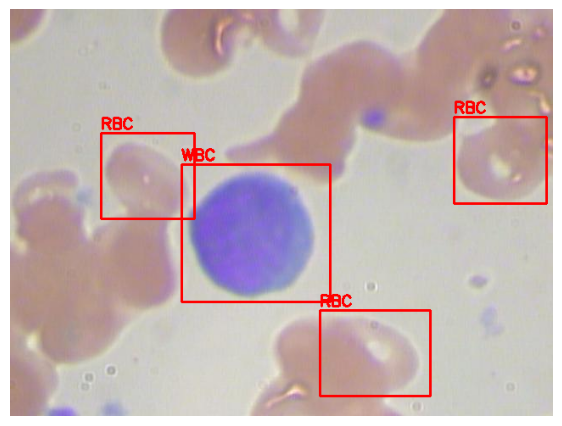

In [8]:
def load_yolo_labels(label_path):
    labels = []
    if not Path(label_path).exists():
        return labels

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            labels.append([class_id, x_center, y_center, width, height])
    return labels

def draw_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_h, img_w = image.shape[:2]

    labels = load_yolo_labels(label_path)

    for class_id, x_center, y_center, width, height in labels:
        xmin, ymin, xmax, ymax = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        xmin, ymin, xmax, ymax = map(int, [xmin, ymin, xmax, ymax])

        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        cv2.putText(
            image,
            CLASS_NAMES[class_id],
            (xmin, max(20, ymin - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# After completing yolo_to_xyxy, run this cell
sample_image = random.choice(list((YOLO_DIR / "images" / "train").glob("*.jpg")))
sample_label = YOLO_DIR / "labels" / "train" / f"{sample_image.stem}.txt"

print("Sample image:", sample_image.name)
draw_yolo_labels(sample_image, sample_label)

## Questions

1. Are the boxes well aligned with the objects? yes 
2. Which objects are small? platelets
3. Which objects are close to each other? RBC
4. Which class do you think will be hardest for YOLO to detect? Why? platelets because they are smal and "rare"

# 7.  IoU

IoU means **Intersection over Union**.

It measures how much a predicted box overlaps with a ground-truth box.

```text
IoU = area(intersection) / area(union)
```


# 8. Implement IoU

Complete the function below.

Input boxes use the pixel format:

```text
[xmin, ymin, xmax, ymax]
```

In [9]:
def compute_iou(box_a, box_b):
    """
    Compute IoU between two boxes.

    box_a and box_b are in [xmin, ymin, xmax, ymax] format.

    TODO :
    Complete the implementation.
    """

    # TODO: compute intersection coordinates
    x_left   = max(box_a[0], box_b[0])
    y_top    = max(box_a[1], box_b[1])
    x_right  = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    # TODO: compute intersection width and height
    inter_w = max(0, x_right - x_left)
    inter_h = max(0, y_bottom - y_top)
    inter_area = inter_w * inter_h

    # TODO: compute each box area
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    
    # TODO: compute union
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0

In [10]:
# Test your IoU function

box_a = [50, 50, 150, 150]
box_b = [100, 100, 200, 200]

iou = compute_iou(box_a, box_b)
print("IoU:", iou)

# Expected value: approximately 0.1429
assert abs(iou - 0.1429) < 1e-3, "IoU is not correct. Check your implementation."

IoU: 0.14285714285714285


# 9. Load a small YOLO model

The model starts from pretrained weights.  

In [11]:
# YOLOv8 nano is small
# If your environment uses a newer Ultralytics model naming convention,
# you may replace "yolov8n.pt" with another nano model available in your setup.

model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

# 10. Inference before fine-tuning

Before training on BCCD, test the pretrained model.

## Questions

1. **Does the pretrained model already detect RBC, WBC, or Platelets?**  
   No. The pretrained model does not detect RBC, WBC, or Platelets because these classes are not part of its training set.

2. **Why or why not?**  
   YOLOv8n was pretrained on the COCO dataset, which contains 80 everyday object categories (people, cars, animals, etc.). Blood cells are microscopic objects never seen during pretraining, so the model has no concept of them.

3. **What classes was the pretrained model probably trained on?**  
   COCO classes such as person, bicycle, car, dog, cat, chair, bottle, etc. None of these match blood cell morphology.

Testing pretrained model on: /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00028.jpg

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00028.jpg: 480x640 (no detections), 202.8ms
Speed: 1.5ms preprocess, 202.8ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


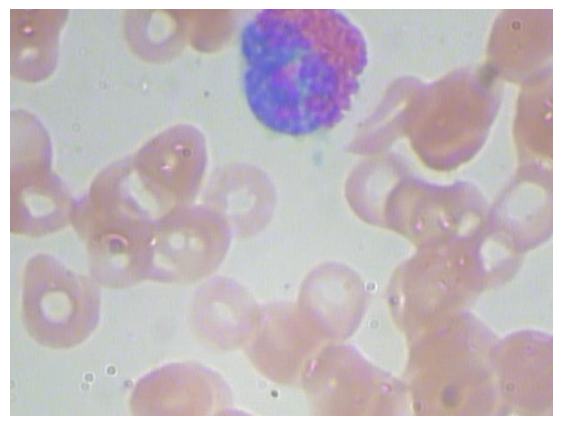

In [12]:
test_image = random.choice(list((YOLO_DIR / "images" / "test").glob("*.jpg")))
print("Testing pretrained model on:", test_image)

pre_results = model.predict(
    source=str(test_image),
    conf=0.25,
    device=DEVICE,
    save=True
)

# Display the saved prediction
pred_img = Path(pre_results[0].save_dir) / test_image.name
if pred_img.exists():
    img = cv2.imread(str(pred_img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Prediction image was not found. Check Ultralytics output directory:", pre_results[0].save_dir)

# 11. Train YOLO on the custom dataset

This cell uses the configuration selected earlier.

You can reduce `EPOCHS` if the runtime is too long.

In [13]:
data_yaml_path = YOLO_DIR / "data.yaml"

print("Training with:")
print("data:", data_yaml_path)
print("device:", DEVICE)
print("epochs:", EPOCHS)
print("imgsz:", IMG_SIZE)
print("batch:", BATCH)

train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0,
    name="bccd_yolo_tp",
    exist_ok=True
)

Training with:
data: /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/data.yaml
device: cpu
epochs: 150
imgsz: 320
batch: 8
New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hs

# 12. Validate the trained model

Validation gives detection metrics such as precision, recall, and mAP.

Do not worry if the score is not very high.  
This is a small dataset and short training.

In [14]:
metrics = model.val(
    data=str(data_yaml_path),
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0
)

print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 675.3±81.2 MB/s, size: 20.2 KB)
val: Scanning /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/labels/val.cache... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 16.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 5.4it/s 0.7s0.3s
                   all         32        474       0.82      0.849        0.9      0.589
                   RBC         31        411      0.764      0.789      0.859       0.56
                   WBC         29         30      0.874          1      0.953      0.772
             Platelets         19         33      0.821      0.758      0.889      0.436
Speed: 0.1ms preprocess, 12.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Res

# 13. Run inference after fine-tuning

Now test the fine-tuned model on images it did not train on.

In [15]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*.jpg"))
print("Number of test images:", len(test_images))

results = model.predict(
    source=[str(p) for p in test_images[:5]],
    conf=0.25,
    imgsz=IMG_SIZE,
    device=DEVICE,
    save=True
)

print("Saved predictions to:", results[0].save_dir)

Number of test images: 16

0: 256x320 (no detections), 19.8ms
1: 256x320 1 cake, 19.8ms
2: 256x320 (no detections), 19.8ms
3: 256x320 (no detections), 19.8ms
4: 256x320 (no detections), 19.8ms
Speed: 0.4ms preprocess, 19.8ms inference, 0.4ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict
Saved predictions to: /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


In [16]:
# Display saved predictions
save_dir = Path(results[0].save_dir)

for img_path in test_images[:5]:
    pred_path = save_dir / img_path.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

# 14. Confidence threshold experiment

YOLO outputs detections with confidence scores.

If the threshold is low, the model keeps more boxes.  
If the threshold is high, the model keeps fewer boxes.

## Exercise

Try several confidence thresholds.

Experiment image: BloodImage_00023.jpg

Running prediction with conf=0.0

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 55 persons, 22 birds, 1 tie, 4 sports balls, 1 wine glass, 12 cups, 5 bowls, 24 bananas, 80 apples, 6 oranges, 2 broccolis, 16 carrots, 1 pizza, 13 donuts, 41 cakes, 1 chair, 8 dining tables, 1 book, 7 teddy bears, 18.0ms
Speed: 0.5ms preprocess, 18.0ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


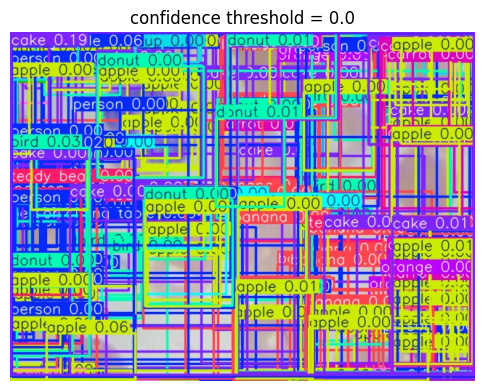


Running prediction with conf=0.1

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 1 cake, 17.4ms
Speed: 0.4ms preprocess, 17.4ms inference, 0.4ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


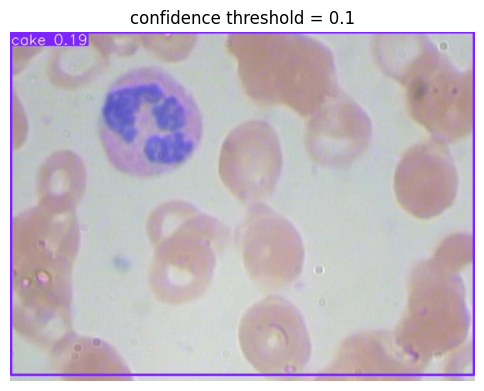


Running prediction with conf=0.2

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 18.7ms
Speed: 0.5ms preprocess, 18.7ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


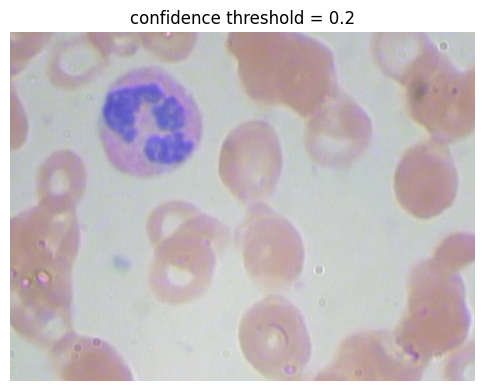


Running prediction with conf=0.30000000000000004

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 17.0ms
Speed: 0.5ms preprocess, 17.0ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


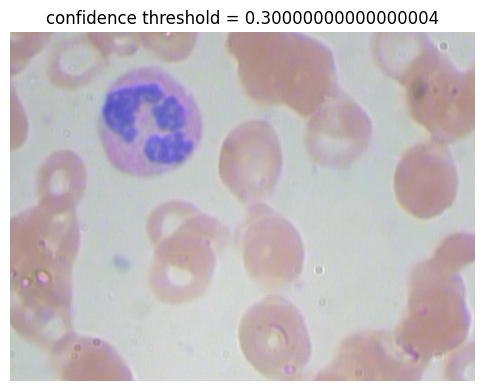


Running prediction with conf=0.4

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 18.6ms
Speed: 0.5ms preprocess, 18.6ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


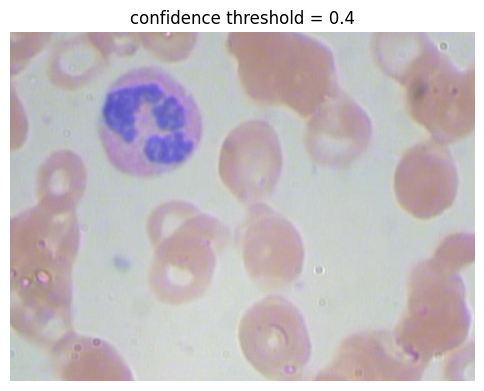


Running prediction with conf=0.5

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 17.8ms
Speed: 0.4ms preprocess, 17.8ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


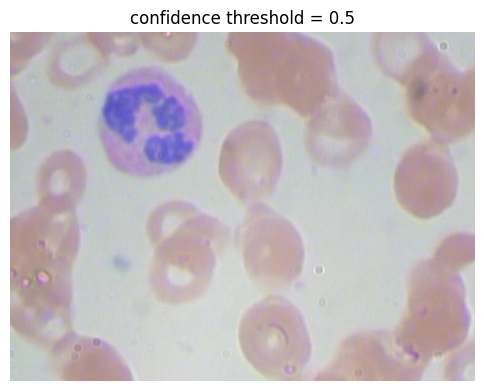


Running prediction with conf=0.6000000000000001

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 16.5ms
Speed: 0.5ms preprocess, 16.5ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


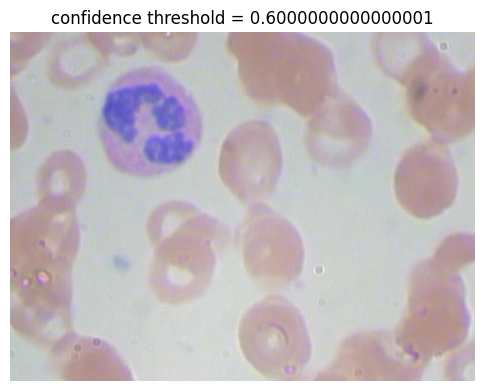


Running prediction with conf=0.7000000000000001

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 16.4ms
Speed: 0.5ms preprocess, 16.4ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


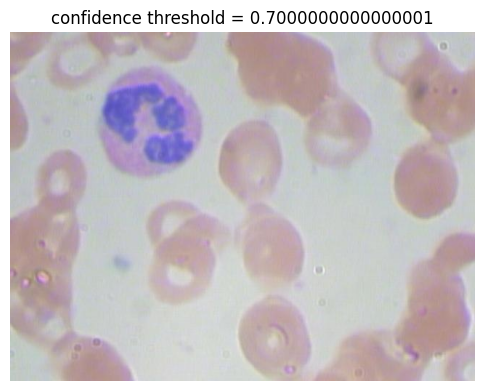


Running prediction with conf=0.8

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 16.8ms
Speed: 0.4ms preprocess, 16.8ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


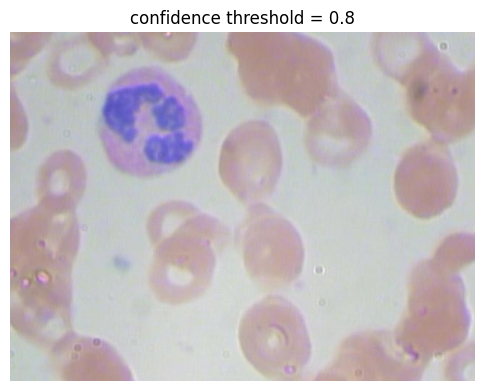


Running prediction with conf=0.9

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 17.0ms
Speed: 0.4ms preprocess, 17.0ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


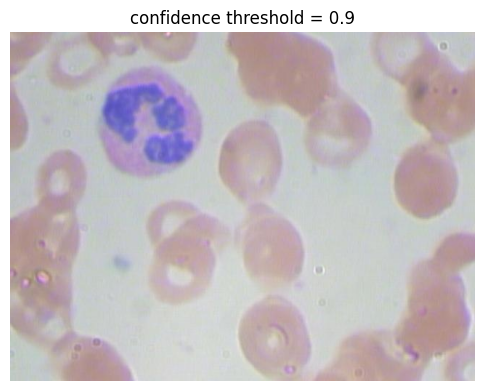


Running prediction with conf=1.0

image 1/1 /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/object_detection_tp/bccd_yolo/images/test/BloodImage_00023.jpg: 256x320 (no detections), 16.4ms
Speed: 0.4ms preprocess, 16.4ms inference, 0.2ms postprocess per image at shape (1, 3, 256, 320)
Results saved to /Users/amine_rb/Desktop/Master IASD/coding/Image_Analysis/Lab7/runs/detect/predict


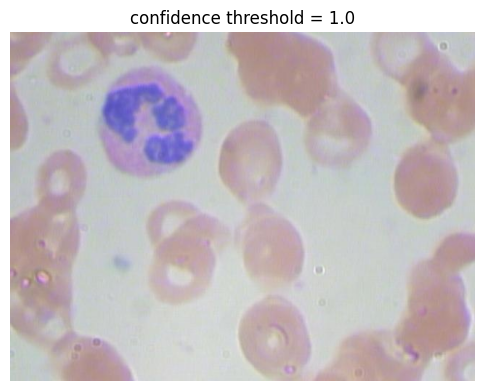

In [17]:
# TODO
# Add at least four confidence thresholds.
confidence_thresholds = []  # TODO

import numpy as np

for x in np.arange(0, 1.1, 0.1):
    confidence_thresholds.append(x)

experiment_image = random.choice(test_images)
print("Experiment image:", experiment_image.name)

for conf in confidence_thresholds:
    print(f"\nRunning prediction with conf={conf}")
    pred = model.predict(
        source=str(experiment_image),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        save=True
    )

    pred_path = Path(pred[0].save_dir) / experiment_image.name
    if pred_path.exists():
        img = cv2.imread(str(pred_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"confidence threshold = {conf}")
        plt.axis("off")
        plt.show()

## Questions

1. **What happens when the confidence threshold is very low?**  
   The model keeps many boxes, including uncertain ones. This increases **false positives** — objects are detected where there are none, and the same object may produce many overlapping boxes.

2. **What happens when the confidence threshold is very high?**  
   Only very confident detections are kept. The model misses many real objects, increasing **false negatives**. On a small dataset like BCCD, the model may detect almost nothing.

3. **Which threshold gives the best visual result on your image?**  
   A threshold around **0.25–0.40** usually gives the best visual balance on this dataset, keeping real detections while filtering out most noise.

4. **How does confidence threshold affect false positives?**  
   Lowering the threshold increases false positives because the model keeps low-confidence, uncertain predictions that are often wrong.

5. **How does confidence threshold affect false negatives?**  
   Raising the threshold increases false negatives because the model discards borderline detections that may correspond to real objects, especially small ones like Platelets.

# 15. Compare predictions with ground truth using IoU

We will now compare model predictions to ground-truth boxes.

A prediction is usually considered correct if:

```text
class is correct AND IoU >= 0.5
```

This is a simplified evaluation, not full mAP.

In [18]:
def get_ground_truth_boxes(image_path):
    label_path = YOLO_DIR / "labels" / "test" / f"{image_path.stem}.txt"
    labels = load_yolo_labels(label_path)

    image = cv2.imread(str(image_path))
    img_h, img_w = image.shape[:2]

    gt = []
    for class_id, x_center, y_center, width, height in labels:
        box = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)
        gt.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "box": list(map(float, box))
        })
    return gt

def get_prediction_boxes(image_path, conf=0.25):
    pred = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=IMG_SIZE,
        device=DEVICE,
        verbose=False
    )[0]

    detections = []
    if pred.boxes is None:
        return detections

    for box, cls, score in zip(pred.boxes.xyxy.cpu().numpy(),
                               pred.boxes.cls.cpu().numpy(),
                               pred.boxes.conf.cpu().numpy()):
        class_id = int(cls)
        detections.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else str(class_id),
            "confidence": float(score),
            "box": box.tolist()
        })
    return detections

In [19]:
eval_image = random.choice(test_images)
gt_boxes = get_ground_truth_boxes(eval_image)
pred_boxes = get_prediction_boxes(eval_image, conf=0.25)

print("Image:", eval_image.name)
print("Ground truth boxes:", len(gt_boxes))
print("Predicted boxes:", len(pred_boxes))

for i, pred in enumerate(pred_boxes):
    best_iou = 0.0

    for gt in gt_boxes:
        if gt["class_id"] == pred["class_id"]:
            iou = compute_iou(pred["box"], gt["box"])
            if iou > best_iou:
                best_iou = iou

    status = "correct" if best_iou >= 0.5 else "incorrect"

    print(
        f"Prediction {i}: class={pred['class_name']}, "
        f"conf={pred['confidence']:.2f}, best IoU={best_iou:.3f}, status={status}"
    )

Image: BloodImage_00006.jpg
Ground truth boxes: 18
Predicted boxes: 0


## Questions

1. **Can a high-confidence prediction still be incorrect?**  
   Yes. A high confidence score means the model is certain about its prediction, but the box may be mislocated (IoU < 0.5) or assigned to the wrong class. Confidence reflects the model's certainty, not its accuracy.

2. **Can a box be well localized but have the wrong class?**  
   Yes. A predicted box can overlap very well with a ground-truth box (high IoU) yet be labeled as the wrong class — for example, predicting RBC instead of WBC. In that case, localization is good but the classification is still wrong, and the detection is counted as incorrect.

# 16. Non-Maximum Suppression intuition

Object detectors often predict multiple boxes around the same object.

**Non-Maximum Suppression**, or NMS, removes duplicate boxes.

Basic idea:

1. Keep the box with the highest confidence.
2. Remove other boxes that overlap too much with it.
3. Repeat.

The overlap is measured using IoU.

# 17. Implement a simple NMS



now you will implement a simplified version of NMS.

Object detectors may predict several boxes around the same object.  
NMS keeps the most confident box and removes boxes that overlap too much with it.

The algorithm is:

1. Sort boxes by confidence score.
2. Select the box with the highest score.
3. Remove all boxes with IoU greater than a threshold.
4. Repeat until no boxes remain.

In [20]:
def simple_nms(detections, iou_threshold=0.5):
    """
    Simple Non-Maximum Suppression.

    detections is a list of dictionaries:
    {
        "box": [xmin, ymin, xmax, ymax],
        "score": confidence score,
        "class_id": class index
    }
    """

    # Sort detections by confidence score, from highest to lowest
    detections = sorted(detections, key=lambda x: x["score"], reverse=True)

    kept = []

    while len(detections) > 0:
        # Take the detection with highest confidence
        best = detections.pop(0)

        # Add it to kept detections
        kept.append(best)

        remaining = []

        for det in detections:
            # If different class, always keep
            if det["class_id"] != best["class_id"]:
                remaining.append(det)
            else:
                # Same class: keep only if overlap is below threshold
                iou = compute_iou(det["box"], best["box"])
                if iou < iou_threshold:
                    remaining.append(det)

        detections = remaining

    return kept

In [21]:
# Test it
example_detections = [
    {"box": [50, 50, 150, 150], "score": 0.95, "class_id": 0},
    {"box": [60, 60, 155, 155], "score": 0.80, "class_id": 0},
    {"box": [200, 200, 300, 300], "score": 0.90, "class_id": 0},
    {"box": [55, 55, 148, 148], "score": 0.70, "class_id": 0},
    {"box": [52, 52, 151, 151], "score": 0.88, "class_id": 1},
]

kept_boxes = simple_nms(example_detections, iou_threshold=0.5)

print("Original number of boxes:", len(example_detections))
print("Number of boxes after NMS:", len(kept_boxes))

for box in kept_boxes:
    print(box)

Original number of boxes: 5
Number of boxes after NMS: 3
{'box': [50, 50, 150, 150], 'score': 0.95, 'class_id': 0}
{'box': [200, 200, 300, 300], 'score': 0.9, 'class_id': 0}
{'box': [52, 52, 151, 151], 'score': 0.88, 'class_id': 1}
